In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# DeepGlobe Class Mapping (Jo humne use ki thi)
CLASS_COLORS = {
    'urban': [0, 255, 255],       # Cyan
    'agriculture': [255, 255, 0], # Yellow
    'rangeland': [255, 0, 255],   # Magenta
    'forest': [0, 255, 0],        # Green
    'water': [0, 0, 255],         # Blue
    'barren': [255, 255, 255],    # White
    'unknown': [0, 0, 0]          # Black
}

def analyze_afforestation_potential(predicted_mask, pixel_resolution_meters=2.0):
    """
    Predicted mask se barren land calculate karega aur tree recommendation dega.
    pixel_resolution_meters: 1 pixel kitne meter ka hai (DeepGlobe mein approx 1 pixel = 2 meters)
    """
    # Total pixels
    total_pixels = predicted_mask.shape[0] * predicted_mask.shape[1]
    
    # Maan lete hain class indices: 0: urban, 1: agri, 2: range, 3: forest, 4: water, 5: barren
    # (Apne model ke exact index se match kar lena, assuming 5 is Barren)
    barren_mask = (predicted_mask == 5)
    rangeland_mask = (predicted_mask == 2)
    water_mask = (predicted_mask == 4)
    
    barren_pixels = np.sum(barren_mask)
    rangeland_pixels = np.sum(rangeland_mask)
    
    # Area calculation (Area = pixels * resolution^2)
    pixel_area_sq_m = pixel_resolution_meters ** 2
    barren_area_sq_m = barren_pixels * pixel_area_sq_m
    
    print("====== 🌳 AFFORESTATION SITE ANALYSIS ======")
    print(f"🏜️ Barren Land Detected: {barren_pixels} pixels ({barren_area_sq_m:.2f} sq meters)")
    print(f"🌿 Rangeland Detected: {rangeland_pixels} pixels")
    
    # RECOMMENDATION LOGIC (Rule-based Engine)
    print("\n🤖 PLANTATION RECOMMENDATION:")
    
    if barren_pixels == 0 and rangeland_pixels == 0:
        print("✅ Is area mein pehle se hi kafi greenery/urbanization hai. No immediate barren land found!")
        return
        
    if barren_pixels > 0:
        print("- 📍 Action: Priority 1 - Afforestation needed on White (Barren) patches.")
        # Paani ke paas check karne ka jugad (Distance transform ya simple check)
        if np.sum(water_mask) > 0:
            print("  💧 Water body nearby! Suggestion: Plant moisture-loving trees like Bamboo or Willow near banks.")
        print("  🏜️ Dry Zone Suggestion: Plant drought-resistant species like Neem, Acacia (Babool), or Shisham.")
        
    # Tree count estimation (assuming 1 tree needs approx 16 sq meters of space)
    estimated_trees = barren_area_sq_m / 16
    print(f"\n🔢 Estimated Tree Capacity: Approx {int(estimated_trees)} trees can be planted here!")
    print("============================================")

# Test karne ke liye (Dummy mask check)
# dummy_mask = np.random.randint(0, 6, (512, 512))
# analyze_afforestation_potential(dummy_mask)

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_afforestation_report(pred_mask, pixel_res_meters=1.0):
    """
    Model ke predicted mask se banjar zameen ka area aur tree capacity nikalna.
    DeepGlobe Dataset Classes Mapping:
    0: Urban, 1: Agriculture, 2: Rangeland, 3: Forest, 4: Water, 5: Barren, 6: Unknown
    """
    # 1. Total pixels aur Resolution Setup
    total_pixels = pred_mask.size
    pixel_area_sq_m = pixel_res_meters ** 2  # 1 pixel ka area sq meters mein
    
    # 2. Masks extract karein (DeepGlobe index ke hisab se)
    barren_mask = (pred_mask == 5)      # White color (Banjar Zameen)
    rangeland_mask = (pred_mask == 2)   # Magenta color (Khali jhaadiyo wali zameen)
    water_mask = (pred_mask == 4)       # Blue color (Paani)
    
    # Pixel counts
    barren_pixels = np.sum(barren_mask)
    rangeland_pixels = np.sum(rangeland_mask)
    has_water_nearby = np.sum(water_mask) > 500  # Agar significant paani hai tabhi true
    
    # 3. Area Calculations
    barren_area_sq_m = barren_pixels * pixel_area_sq_m
    rangeland_area_sq_m = rangeland_pixels * pixel_area_sq_m
    total_plantable_area = barren_area_sq_m + rangeland_area_sq_m
    
    # Hectares mein convert karein (1 Hectare = 10,000 sq meters)
    total_hectares = total_plantable_area / 10000
    
    # 4. Tree Capacity Estimation (Standard rule: 1 ped ko approx 16 sq meters jagah chahiye)
    space_per_tree_sq_m = 16.0 
    estimated_tree_capacity = int(total_plantable_area / space_per_tree_sq_m)
    
    # 5. Print out Report
    print("\n" + "="*50)
    print("🌳 AI AFFORESTATION SITE ANALYTICS REPORT 🌳")
    print("="*50)
    print(f"🏜️ Banjar Zameen (Barren Land): {barren_area_sq_m:.2f} sq meters")
    print(f"🌿 Khali Jhaadiyan (Rangeland):  {rangeland_area_sq_m:.2f} sq meters")
    print(f"📐 Total Plantable Area:         {total_plantable_area:.2f} sq meters ({total_hectares:.4f} Hectares)")
    print(f"🔢 Estimated Tree Capacity:      {estimated_tree_capacity} Trees can be planted here!")
    print("-"*50)
    
    # 6. Smart Species Recommendation Engine
    print("🤖 ECO-SYSTEM TREE SPECIES RECOMMENDATION:")
    if estimated_tree_capacity == 0:
        print("✅ Is area mein pehle se hi kaafi greenery ya construction hai. No planting needed!")
    else:
        if barren_pixels > 0:
            print("👉 Dry Zone (Barren Land) Species suggested:")
            print("   - Neem (Azadirachta indica) [Highly sustainable]")
            print("   - Acacia / Babool [Drought resistant]")
            print("   - Shisham / Indian Rosewood [High timber value]")
            
        if rangeland_pixels > 0:
            print("👉 Semi-Arid Zone (Rangeland) Species suggested:")
            print("   - Khejri Tree [Excellent for soil enrichment]")
            print("   - Amaltas (Golden Shower Tree) [Eco-balance]")
            
        if has_water_nearby:
            print("💧 WATER BODY DETECTED NEARBY!")
            print("   - Suggestion: Plant Moisture-loving trees like Bamboo or Willow along boundaries to prevent soil erosion.")
            
    print("="*50 + "\n")
    
    # Visual Mask for Afforestation Zone
    # Plantable zones ko green custom highlight dikhane ke liye
    overlay = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
    overlay[barren_mask] = [255, 0, 0]      # Barren land ko Red color se highlight karein
    overlay[rangeland_mask] = [255, 165, 0] # Rangeland ko Orange se highlight karein
    
    return overlay

d:\project data\AI_afforestation\ai_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔄 Initializing dataset and loading model weights...
✅ Loaded model from d:\project data\AI_afforestation\checkpoints\best_deeplab_model.pth
🎯 Selected Validation Image Index: 248

🌳 AI AFFORESTATION SITE ANALYTICS REPORT 🌳
🏜️ Banjar Zameen (Barren Land): 999500.00 sq meters
🌿 Khali Jhaadiyan (Rangeland):  0.00 sq meters
📐 Total Plantable Area:         999500.00 sq meters (99.9500 Hectares)
🔢 Estimated Tree Capacity:      62468 Trees can be planted here!
--------------------------------------------------
🤖 ECO-SYSTEM TREE SPECIES RECOMMENDATION:
👉 Dry Zone (Barren Land) Species suggested:
   - Neem (Azadirachta indica) [Highly sustainable]
   - Acacia / Babool [Drought resistant]
   - Shisham / Indian Rosewood [High timber value]



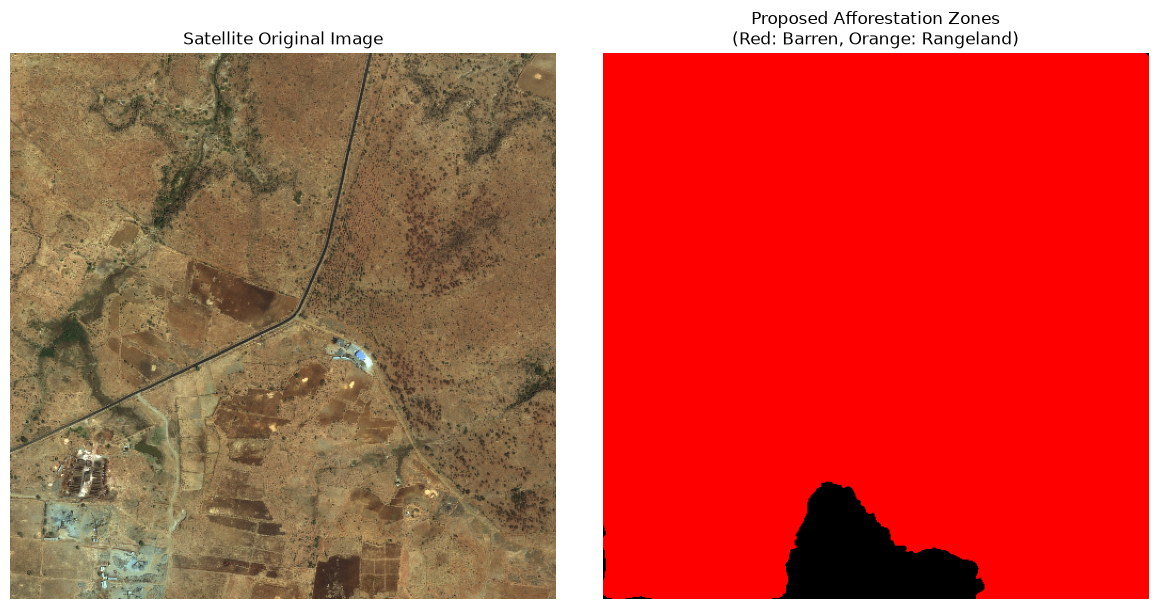

In [6]:
import os
import sys
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Path Setup aur Verification
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Dataset ka sahi path dhundhna (Pichli automatic logic)
path_option_1 = os.path.join(PROJECT_ROOT, "datasets", "DeepGlobeDataset", "train")
path_option_2 = os.path.join(PROJECT_ROOT, "datasets", "DeepGlobeDataset")
train_dir = path_option_1 if os.path.exists(path_option_1) and any(f.endswith('_sat.jpg') for f in os.listdir(path_option_1)) else path_option_2

weight_path = os.path.join(PROJECT_ROOT, "checkpoints", "best_deeplab_model.pth")

# 2. Imports aur Dataset/Model Re-Initialization
from models.segmentation.dataset import DeepGlobeDataset
from models.segmentation.predict import load_saved_model

print("🔄 Initializing dataset and loading model weights...")
dataset = DeepGlobeDataset(image_dir=train_dir, mask_dir=train_dir, image_size=512)
model, device = load_saved_model(weight_path=weight_path, num_classes=7)
model.eval()

# 3. Random Image Selection
random_idx = random.randint(0, len(dataset) - 1)
image_tensor, mask_tensor = dataset[random_idx]
print(f"🎯 Selected Validation Image Index: {random_idx}")

# 4. Model Inference (Prediction)
with torch.no_grad():
    output = model(image_tensor.unsqueeze(0).to(device))
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# 5. Analytics Report Generation
# ( ensure generate_afforestation_report cell was run before this )
planting_overlay = generate_afforestation_report(pred_mask, pixel_res_meters=2.0)

# 6. Final Visualisation Plots
img_display = image_tensor.permute(1, 2, 0).cpu().numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Satellite Original Image")
plt.imshow(img_display)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Proposed Afforestation Zones\n(Red: Barren, Orange: Rangeland)")
plt.imshow(planting_overlay)
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import os
import sys

# 1. Project root setup
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 2. Service file se fetcher class import karna
from services.environment_api import EnvironmentDataFetcher

# 3. Apni real OpenWeather API Key yahan daalna
API_KEY = "c72ab2d7e534b8b544f10f3aebd15710"  # ← Ab quotes lag gaye hain!

fetcher = EnvironmentDataFetcher(api_key=API_KEY)
# Delhi coordinates par test karna
profile = fetcher.get_full_environmental_profile(lat=28.6139, lon=77.2090)

print("📊 LIVE ENVIRONMENTAL PROFILE FROM API:")
print(profile)

🌐 Fetching environmental profile for Lat: 28.6139, Lon: 77.209...
📊 LIVE ENVIRONMENTAL PROFILE FROM API:
{'status': 'error', 'message': 'Weather API Failed: 401'}


In [15]:
from models.recommendation.tree_engine import TreeRecommendationEngine

# 1. Engine Instance create karna
recommender = TreeRecommendationEngine()

# 2. Pichle cell ka environmental profile fetch check karna
if 'profile' in locals() and profile.get('status') in ['success', 'success_fallback']:
    env_data = profile['profile']
else:
    # Safe backup agar variable delete ho gaya ho
    env_data = {
        "weather": {"temperature": 32.5, "humidity": 45.0},
        "air_quality": {"aqi_index": 3}
    }

# 3. Model 1 ke dynamic zones ke liye inference test run karna
print("="*60)
print(f"🌲 AI AFFORESTATION ENGINE RESULTS FOR LOCATION: {env_data.get('location')}")
print("="*60)

for zone in ["barren", "rangeland"]:
    print(f"\n🏜️ Target Land Category Type: [{zone.upper()}]")
    recommendations = recommender.recommend_trees(land_type=zone, env_profile=env_data)
    
    if len(recommendations) == 0:
        print("  • Koi species ideal nahi mili is critical climate conditions mein.")
    for idx, rec in enumerate(recommendations, 1):
        print(f"  {idx}. 🌳 {rec['tree_name']:15} | Core: {rec['type']:18} | Match Score: {rec['match_score']}%")
        
print("="*60)

🌲 AI AFFORESTATION ENGINE RESULTS FOR LOCATION: None

🏜️ Target Land Category Type: [BARREN]
  1. 🌳 Neem            | Core: Drought Resistant  | Match Score: 100%
  2. 🌳 Acacia (Babool) | Core: Arid Hardy         | Match Score: 100%
  3. 🌳 Shisham         | Core: Timber Value       | Match Score: 100%
  4. 🌳 Khejri          | Core: Desert Special     | Match Score: 100%

🏜️ Target Land Category Type: [RANGELAND]
  1. 🌳 Neem            | Core: Drought Resistant  | Match Score: 100%
  2. 🌳 Shisham         | Core: Timber Value       | Match Score: 100%
  3. 🌳 Amaltas         | Core: Eco-Balancer       | Match Score: 100%
  4. 🌳 Bamboo          | Core: Soil Binder        | Match Score: 85%


In [17]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error

def train_afforestation_ml_core():
    dataset_path = "datasets/master/master_dataset.csv"
    if not os.path.exists(dataset_path):
        print(f"❌ Master dataset missing at {dataset_path}! Pehle generator script chalayein.")
        return

    # 1. Load Master Dataset
    df = pd.read_csv(dataset_path)
    print("📋 Master Dataset Loaded Successfully. Shape:", df.shape)

    # 2. Categorical Features ko Encode karna (Land_Type, Soil_Type)
    le_land = LabelEncoder()
    le_soil = LabelEncoder()
    le_tree = LabelEncoder()

    df['Land_Type_Enc'] = le_land.fit_transform(df['Land_Type'])
    df['Soil_Type_Enc'] = le_soil.fit_transform(df['Soil_Type'])
    df['Best_Tree_Enc'] = le_tree.fit_transform(df['Best_Tree'])

    # Features selection according to Schema Step 2
    feature_cols = [
        'Vegetation_Percentage', 'Water_Nearby', 'Land_Type_Enc', 'Soil_Type_Enc', 
        'pH', 'Moisture', 'Temperature', 'Rainfall', 'Humidity', 'AQI', 'Elevation'
    ]
    
    X = df[feature_cols]
    y_tree = df['Best_Tree_Enc']               # Model 2 Target
    y_survival = df['Survival_Probability']    # Model 3 Target

    # Train-Test Split
    X_train, X_test, y_tree_train, y_tree_test, y_surv_train, y_surv_test = train_test_split(
        X, y_tree, y_survival, test_size=0.2, random_state=42
    )

    # 3. Model 2: Train Tree Recommendation Classifier
    print("🤖 Training Model 2 (Tree Recommendation Classifier)...")
    clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_model.fit(X_train, y_tree_train)
    
    tree_preds = clf_model.predict(X_test)
    acc = accuracy_score(y_tree_test, tree_preds)
    print(f"✅ Model 2 Accuracy: {acc*100:.2f}%")

    # 4. Model 3: Train Survival Probability Regressor
    print("🤖 Training Model 3 (Survival Probability Regressor)...")
    reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
    reg_model.fit(X_train, y_surv_train)
    
    surv_preds = reg_model.predict(X_test)
    mae = mean_absolute_error(y_surv_test, surv_preds)
    print(f"✅ Model 3 Mean Absolute Error: {mae:.2f}%")

    # 5. Checkpoints Save Karna
    os.makedirs("checkpoints", exist_ok=True)
    joblib.dump(clf_model, "checkpoints/tree_recommender.pkl")
    joblib.dump(reg_model, "checkpoints/survival_regressor.pkl")
    
    # Encoders save karna taaki backend inference ke waqt kaam aayein
    encoders = {'land': le_land, 'soil': le_soil, 'tree': le_tree, 'features': feature_cols}
    joblib.dump(encoders, "checkpoints/ml_encoders.pkl")
    
    print("💾 All ML Core Checkpoints saved successfully in 'checkpoints/' folder!")

if __name__ == "__main__":
    train_afforestation_ml_core()

❌ Master dataset missing at datasets/master/master_dataset.csv! Pehle generator script chalayein.


In [1]:
import os
import sys

# 1. Path routing setup
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Root directory par switch karna taaki path conflicts na hon
os.chdir(PROJECT_ROOT)

# 2. Generator ko pehle call karna
from preprocessing.dataset_generator import generate_master_dataset
print("⏳ Step A: Simulating Master Dataset based on Schema Rules...")
generate_master_dataset(num_samples=1200)

# 3. Training core call karna
from models.recommendation.train_ml_core import train_afforestation_ml_core
print("\n⏳ Step B: Training ML Classification and Regression Engines...")
train_afforestation_ml_core()

⏳ Step A: Simulating Master Dataset based on Schema Rules...
✅ CSV Generated at: datasets/master/master_dataset.csv | Shape: (1200, 14)

⏳ Step B: Training ML Classification and Regression Engines...
📋 Master Dataset Loaded. Shape: (1200, 14)
🤖 Training Model 2 (Tree Recommendation Classifier)...
✅ Model 2 Accuracy: 92.50%
🤖 Training Model 3 (Survival Probability Regressor)...
✅ Model 3 Mean Absolute Error: 2.16%
💾 All ML Core Checkpoints saved successfully in 'checkpoints/'!
